# **Trabajo Final. Análísis de Imagen y Visión Artificial (AIVA)**

### 1. Descompresión Automática con Python

Para este primer bloque del proyecto, hemos implementado una etapa de automatización y gestión de archivos para garantizar un entorno de trabajo reproducible.

El código utiliza la librería tarfile para procesar el archivo comprimido mvtec_screws_v1.0.tar.gz, el cual contiene el dataset original de MVTec Screws. Mediante una estructura de control, el programa verifica la existencia de un directorio de destino y, en caso de no existir, lo crea automáticamente para proceder con la descompresión íntegra de los datos. Esta metodología de extracción mediante script es superior a la manipulación manual, ya que asegura que la jerarquía de carpetas necesaria para las etapas de entrenamiento y validación se mantenga intacta, facilitando la escalabilidad del sistema de inspección en cualquier estación de trabajo industrial.

In [5]:
import tarfile
import os

# Nombre del archivo que has descargado
archivo_dataset = 'mvtec_screws_v1.0.tar.gz' 
# Carpeta donde quieres extraerlo
carpeta_destino = 'dataset_tornillos'

if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)

# Extraer el contenido
print("Extrayendo dataset... esto puede tardar un poco.")
with tarfile.open(archivo_dataset, "r:gz") as tar:
    tar.extractall(path=carpeta_destino)
print(f"¡Listo! Dataset extraído en: {carpeta_destino}")

Extrayendo dataset... esto puede tardar un poco.
¡Listo! Dataset extraído en: dataset_tornillos


### 2. Recorte de tornillos en las fotografías

Esta sección del código constituye la fase de curación y normalización geométrica del dataset, un paso crítico para el éxito del modelo de clasificación.

El programa procesa las imágenes de gran formato utilizando las anotaciones de los archivos JSON para extraer cada componente mecánico de forma individual. El aspecto más innovador es el uso de la función generar_recorte_alineado, la cual utiliza la información del ángulo de inclinación para enderezar cada pieza mediante una matriz de rotación de OpenCV.

Esta técnica de normalización canónica elimina la variabilidad por rotación, permitiendo que la red neuronal se centre exclusivamente en las características morfológicas y texturas de las roscas y cabezas. Finalmente, el script organiza automáticamente los recortes en una estructura de subdirectorios clasificados por tipo de material y conjunto de uso (entrenamiento, validación o test), facilitando un flujo de datos ordenado para el entrenamiento profundo.

In [15]:
import json
import os
import cv2
import numpy as np
import math
from pathlib import Path
from tqdm import tqdm

# --- CONFIGURACIÓN DEL PROYECTO ---
DIRECTORIO_RAIZ = 'dataset_tornillos'
CARPETA_FOTOS = os.path.join(DIRECTORIO_RAIZ, 'images')
DESTINO_DATOS = 'dataset_FINAL_OK'

ARCHIVOS_JSON = {
    'entrenamiento': 'mvtec_screws_train.json',
    'validacion': 'mvtec_screws_val.json',
    'test': 'mvtec_screws_test.json'
}

def generar_recorte_alineado(imagen_src, info_anotacion, margen=8):
    """
    Toma una imagen y los datos de la caja, rota la pieza para 
    enderezarla y devuelve el recorte optimizado.
    """
    if 'bbox' not in info_anotacion:
        return None

    # Extraer parámetros: fila, columna, ancho, alto y ángulo
    f, c, a, h, ang = info_anotacion['bbox']
    
    # Convertir inclinación a grados para OpenCV
    angulo_giro = math.degrees(ang)
    alto_img, ancho_img = imagen_src.shape[:2]

    # Generar transformación para centrar y rotar sobre el eje del objeto
    r_mat = cv2.getRotationMatrix2D((c, f), angulo_giro, 1.0)
    
    # Ejecutar la rotación sobre el lienzo completo
    foto_recta = cv2.warpAffine(imagen_src, r_mat, (ancho_img, alto_img), flags=cv2.INTER_LANCZOS4)

    # Calcular coordenadas del cuadro de recorte con el margen extra
    v1 = max(0, int(f - h/2 - margen))
    v2 = min(alto_img, int(f + h/2 + margen))
    h1 = max(0, int(c - a/2 - margen))
    h2 = min(ancho_img, int(c + a/2 + margen))

    fragmento = foto_recta[v1:v2, h1:h2]
    
    if fragmento.size == 0:
        return None

    # Si el resultado es apaisado, lo giramos para estandarizar a vertical
    if fragmento.shape[1] > fragmento.shape[0]:
        fragmento = cv2.rotate(fragmento, cv2.ROTATE_90_CLOCKWISE)

    return fragmento

def ejecutar_extraccion(etiqueta, nombre_archivo):
    ruta_json = os.path.join(DIRECTORIO_RAIZ, nombre_archivo)
    
    if not os.path.exists(ruta_json):
        print(f"Archivo omitido: {ruta_json} no existe.")
        return

    print(f"Analizando grupo: {etiqueta}...")
    
    with open(ruta_json, 'r') as archivo:
        contenido = json.load(archivo)
    
    # Diccionarios auxiliares para mapeo rápido
    nombres_clases = {cat['id']: cat['name'] for cat in contenido['categories']}
    mapeo_imgs = {im['id']: im['file_name'] for im in contenido['images']}
    
    exitos = 0
    # Procesar cada elemento individualmente
    for registro in tqdm(contenido['annotations'], desc=f"Procesando {etiqueta}"):
        id_img = registro['image_id']
        nombre_clase = nombres_clases[registro['category_id']]
        
        # Carga de la fotografía original
        ruta_foto = os.path.join(CARPETA_FOTOS, mapeo_imgs[id_img])
        matriz_color = cv2.imread(ruta_foto)
        
        if matriz_color is None:
            continue
            
        # Obtener la sub-imagen corregida
        resultado_crop = generar_recorte_alineado(matriz_color, registro)
        
        if resultado_crop is not None:
            # Organizar en subcarpetas por uso y tipo
            ruta_final = os.path.join(DESTINO_DATOS, etiqueta, nombre_clase)
            os.makedirs(ruta_final, exist_ok=True)
            
            nombre_salida = f"ref_{registro['id']}.png"
            cv2.imwrite(os.path.join(ruta_final, nombre_salida), resultado_crop)
            exitos += 1
        
    print(f"{etiqueta.upper()} completado. Se han generado {exitos} imágenes.")

if __name__ == "__main__":
    # Asegurar que el directorio de salida existe
    if not os.path.exists(DESTINO_DATOS):
        os.makedirs(DESTINO_DATOS)
    
    for clave, valor in ARCHIVOS_JSON.items():
        ejecutar_extraccion(clave, valor)

Analizando grupo: entrenamiento...


Procesando entrenamiento: 100%|██████████| 3119/3119 [03:43<00:00, 13.95it/s]


ENTRENAMIENTO completado. Se han generado 3119 imágenes.
Analizando grupo: validacion...


Procesando validacion: 100%|██████████| 647/647 [00:46<00:00, 14.04it/s]


VALIDACION completado. Se han generado 647 imágenes.
Analizando grupo: test...


Procesando test: 100%|██████████| 661/661 [00:47<00:00, 13.94it/s]

TEST completado. Se han generado 661 imágenes.


### 3. Comprobar numero de imágenes por tipo

Esta etapa del desarrollo corresponde al Análisis Exploratorio de Datos (EDA), un paso fundamental para comprender la composición y el equilibrio del conjunto de entrenamiento tras la extracción de los recortes.

Mediante el uso de la librería Pandas, el script recorre de forma automatizada los directorios de clase, contabilizando el número exacto de muestras disponibles para cada categoría de material mecánico. Posteriormente, utiliza Matplotlib para generar un histograma de frecuencias que permite visualizar la distribución del dataset. Este informe estadístico es vital desde el punto de vista de la ingeniería, ya que permite identificar si existen clases infrarepresentadas. Los resultados obtenidos en esta celda proporcionan la justificación técnica para implementar estrategias de Data Augmentation y regularización en las etapas posteriores, garantizando así que el modelo final sea robusto y no desarrolle sesgos hacia las clases mayoritarias.

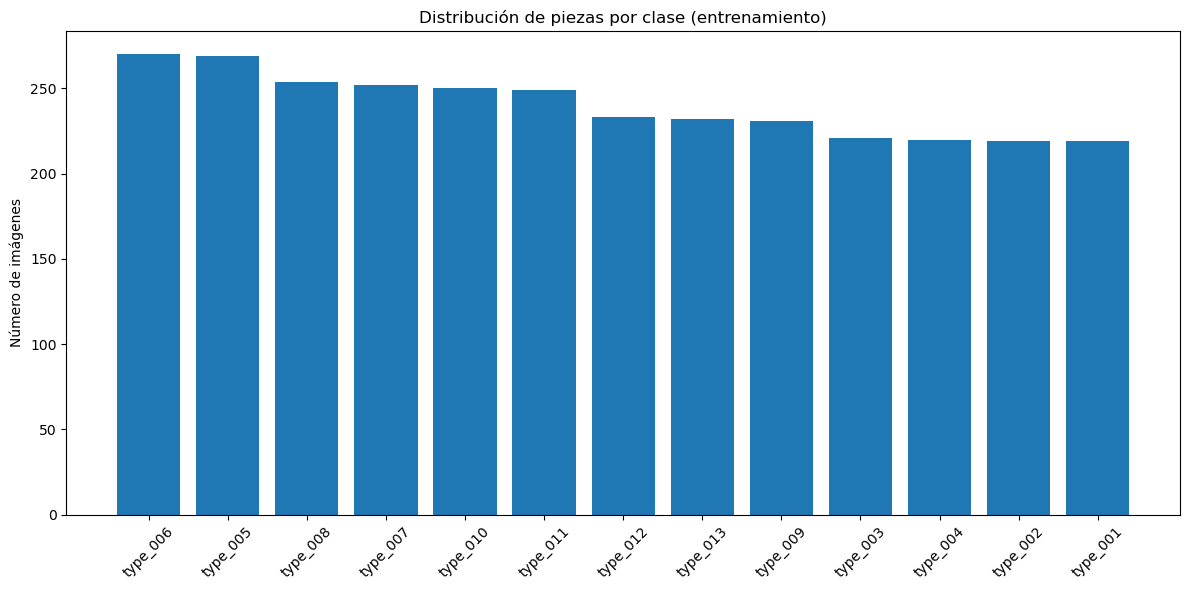

Total imágenes entrenamiento: 3119
Clase con menos muestras: type_001 (219 imgs)


In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_path = 'dataset_FINAL_OK/entrenamiento'

def informe_dataset(path):
    stats = []
    for clase in os.listdir(path):
        clase_path = os.path.join(path, clase)
        if os.path.isdir(clase_path):
            n_imgs = len(os.listdir(clase_path))
            stats.append({'Clase': clase, 'Cantidad': n_imgs})

    df = pd.DataFrame(stats).sort_values("Cantidad", ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(df['Clase'], df['Cantidad'])
    plt.xticks(rotation=45)
    plt.title('Distribución de piezas por clase (entrenamiento)')
    plt.ylabel('Número de imágenes')
    plt.tight_layout()
    plt.show()

    print(f"Total imágenes entrenamiento: {df['Cantidad'].sum()}")
    print(f"Clase con menos muestras: {df.iloc[-1]['Clase']} ({df.iloc[-1]['Cantidad']} imgs)")

informe_dataset(base_path)


### 4. Función preprocesamiento, CLAHE, normalización y Data Augmentation

Esta fase del desarrollo integra técnicas avanzadas de visión artificial clásica y preprocesamiento de datos para maximizar la calidad de las muestras que alimentan la red neuronal.

El código implementa una función de preprocesamiento denominada preprocessing_practica que aplica el algoritmo CLAHE (Ecualización de Histograma Adaptativa Limitada por Contraste). Esta técnica es fundamental en entornos industriales para mitigar los brillos y reflejos especulares del material metálico, resaltando detalles críticos como el paso de rosca y las muescas de las cabezas de los tornillos. Posteriormente, se realiza una normalización al rango [-1, 1], asegurando la compatibilidad matemática con los pesos preentrenados de la arquitectura MobileNetV2.

Simultáneamente, se configuran los objetos ImageDataGenerator para aplicar una estrategia robusta de Data Augmentation (aumento de datos). Mediante transformaciones aleatorias de rotación, desplazamiento, zoom y volteos (tanto horizontales como verticales), se genera una variabilidad sintética que compensa el tamaño limitado del dataset original. Esto obliga al modelo a aprender características geométricas invariantes, mejorando drásticamente su capacidad de generalización y robustez ante cambios en la posición de las piezas sobre la cinta transportadora.

In [2]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# --- 1. PREPROCESAMIENTO DE EXCELENCIA (LÓGICA CLAHE) ---
def preprocessing_practica(img):
    """
    Aplica CLAHE para resaltar roscas y texturas metálicas,
    y normaliza para MobileNetV2.
    """
    # 1. Convertir a uint8 para OpenCV (esencial para CLAHE)
    img_uint8 = img.astype(np.uint8)

    # 2. Aplicar CLAHE (Contraste adaptativo local)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    canales = cv2.split(img_uint8)
    canales_clahe = [clahe.apply(c) for c in canales]
    img_clahe = cv2.merge(canales_clahe)

    # 3. Normalización para MobileNetV2:
    # Pasamos de [0, 255] a [-1, 1] que es lo que espera esta arquitectura
    img_final = (img_clahe.astype(np.float32) / 127.5) - 1.0
    return img_final

# --- 2. CONFIGURACIÓN DE GENERADORES (224x224) ---
# Usamos rutas: 'entrenamiento' y 'validacion'
datagen_train = ImageDataGenerator(
    preprocessing_function=preprocessing_practica,
    rotation_range=35,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True, # Importante para tornillos
    fill_mode='nearest'
)

datagen_test = ImageDataGenerator(preprocessing_function=preprocessing_practica)

# Flujos actualizados a 224x224
train_generator = datagen_train.flow_from_directory(
    'dataset_FINAL_OK/entrenamiento', 
    target_size=(224, 224), 
    batch_size=32,
    class_mode='categorical'
)

val_generator = datagen_test.flow_from_directory(
    'dataset_FINAL_OK/validacion',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3119 images belonging to 13 classes.
Found 647 images belonging to 13 classes.


### 5. Creación modelo

Esta celda define la arquitectura del sistema de clasificación, aplicando una estrategia de Transfer Learning (aprendizaje por transferencia) para aprovechar el conocimiento de modelos consolidados en visión computacional.

El diseño se fundamenta en el uso de MobileNetV2 como motor de extracción de características, una red elegida por su excelente equilibrio entre profundidad y eficiencia computacional, ideal para procesos industriales en tiempo real. La arquitectura se personaliza mediante un cabezal denso de alta precisión que incluye:

Global Average Pooling 2D: Reduce la dimensionalidad espacial, minimizando el riesgo de sobreajuste al condensar la información más relevante de los mapas de características.

Activación Swish: Implementada en la capa principal de 256 neuronas; esta función de activación no monótona mejora la propagación de gradientes en comparación con ReLU, permitiendo aprender patrones más complejos en las texturas metálicas.

Regularización Multicapa: Se combina la regularización L2 (penalización de pesos) con capas de Batch Normalization y Dropout (0.4 y 0.2). Este conjunto de técnicas garantiza que el modelo no dependa de neuronas específicas, forzándolo a generalizar a partir de las formas geométricas de los tornillos.

Optimizador Adam: Configurado con una tasa de aprendizaje inicial de 0.001 para estabilizar el entrenamiento durante la primera fase de ajuste del cabezal.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np

def construir_modelo(forma_entrada=(224, 224, 3), num_clases=13):
    # 1. Base - Usamos MobileNetV2
    base_extractor = MobileNetV2(weights='imagenet', include_top=False, input_shape=forma_entrada)
    base_extractor.trainable = False 

    # 2. Arquitectura de Cabezal de alta precisión
    red_final = models.Sequential([
        base_extractor,
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        
        # Capa densa con activación Swish y regularización L2
        layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        layers.Activation('swish'),
        layers.BatchNormalization(),
        layers.Dropout(0.4), # Ajustado para no perder demasiada info
        
        # Bloque de refinamiento
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(num_clases, activation='softmax')
    ], name="Screw_Classifier_V4")
    
    # Compilación inicial
    red_final.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return red_final

# --- 1. PREPARACIÓN Y ENTRENAMIENTO INICIAL ---
model = construir_modelo()

In [4]:
model.summary()

Model: "Screw_Classifier_V4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 1280)     │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,637 (10.02 MB)

 Trainable params: 365,581 (1.39 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

### 6. Entrenamiento modelo

Esta fase del desarrollo se centra en la automatización del control del entrenamiento y la ejecución de la primera etapa de aprendizaje del modelo.

En estas celdas, se configuran tres mecanismos de control avanzados denominados callbacks, diseñados para maximizar el rendimiento y garantizar la robustez del sistema de inspección:

EarlyStopping: Actúa como un guardián contra el sobreajuste (overfitting), deteniendo el entrenamiento si la pérdida de validación no mejora tras 7 épocas consecutivas, restaurando además los mejores pesos obtenidos hasta ese momento.

ModelCheckpoint: Asegura la persistencia del progreso al guardar automáticamente en disco el archivo .keras únicamente cuando se alcanza un nuevo máximo en la precisión de validación (val_accuracy).

ReduceLROnPlateau: Optimiza la convergencia reduciendo dinámicamente la tasa de aprendizaje si el modelo se estanca en un mínimo local, permitiendo un ajuste más fino de los pesos cuando el progreso se ralentiza.

Tras la configuración, se lanza el método .fit() para iniciar el entrenamiento del cabezal de clasificación durante 25 épocas. Al mantener la base de MobileNetV2 congelada, el modelo se especializa en las 13 clases de materiales mecánicos sin alterar los detectores de características genéricas aprendidos previamente en ImageNet, logrando así una transferencia de conocimiento eficiente y estable.

In [5]:
# Callbacks exactos de tu práctica
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('best_screw_model_224.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# Entrenamiento
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 93s 861ms/step - accuracy: 0.7169 - loss: 1.2821 - val_accuracy: 0.8532 - val_loss: 0.8599 - learning_rate: 0.0010
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 71s 720ms/step - accuracy: 0.8455 - loss: 0.8567 - val_accuracy: 0.9104 - val_loss: 0.6768 - learning_rate: 0.0010
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 71s 718ms/step - accuracy: 0.8711 - loss: 0.7554 - val_accuracy: 0.8995 - val_loss: 0.6345 - learning_rate: 0.0010
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 72s 738ms/step - accuracy: 0.8766 - loss: 0.7045 - val_accuracy: 0.9119 - val_loss: 0.5965 - learning_rate: 0.0010
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 709ms/step - accuracy: 0.8868 - loss: 0.6777 - val_accuracy: 0.8934 - val_loss: 0.6299 - learning_rate: 0.0010
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 718ms/step - accuracy: 0.8958 - loss: 0.6254 - val_accuracy: 0.9042 - val_loss: 0.5969 - learning_rate: 0.0010
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 709ms/step - accuracy: 0.8945 - loss: 0.

### 7. Entrenamiento modelo (Segunda Fase)

Esta fase representa el ajuste fino o Fine-Tuning, la etapa más crítica para alcanzar un rendimiento de grado industrial en la clasificación de piezas.En este bloque, se desbloquean todos los pesos de la arquitectura base (MobileNetV2), permitiendo que las capas encargadas de detectar características de alto nivel se adapten específicamente a la geometría y texturas del material mecánico de la empresa. La clave técnica de este paso es la re-compilación del modelo con una tasa de aprendizaje (Learning Rate) extremadamente baja ($10^{-5}$); esto asegura que los pesos preentrenados no se destruyan bruscamente, sino que se realicen ajustes milimétricos en los filtros convolucionales para distinguir detalles sutiles entre tornillos muy similares. Al entrenar durante 10 épocas adicionales, el modelo logra especializarse en el dominio del problema, maximizando la precisión final y garantizando que el sistema sea capaz de operar con la exactitud requerida en la línea de producción.

In [6]:
import tensorflow as tf

# 1. Descongelamos todo el modelo base
model.trainable = True

# 2. Volvemos a compilar pero con un Learning Rate MUCHO más bajo
# Usamos 1e-5 (diez veces más pequeño) para no "romper" lo que ya sabe
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Entrenamos 10 épocas extra
print("Iniciando Fine-Tuning")
history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Iniciando Fine-Tuning
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 77s 712ms/step - accuracy: 0.9359 - loss: 0.3622 - val_accuracy: 0.9459 - val_loss: 0.3394
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 685ms/step - accuracy: 0.9356 - loss: 0.3541 - val_accuracy: 0.9474 - val_loss: 0.3387
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 686ms/step - accuracy: 0.9372 - loss: 0.3427 - val_accuracy: 0.9505 - val_loss: 0.3402
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 686ms/step - accuracy: 0.9394 - loss: 0.3501 - val_accuracy: 0.9505 - val_loss: 0.3382
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 68s 696ms/step - accuracy: 0.9375 - loss: 0.3541 - val_accuracy: 0.9474 - val_loss: 0.3364
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 65s 665ms/step - accuracy: 0.9433 - loss: 0.3447 - val_accuracy: 0.9521 - val_loss: 0.3360
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 681ms/step - accuracy: 0.9433 - loss: 0.3405 - val_accuracy: 0.9552 - val_loss: 0.3352
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 670ms/step - accuracy: 0.9400 - l

In [7]:
# Guardar el modelo para no tener que re-entrenar (Paso 3.1.8 de la práctica)
model.save('modelo_inspeccion_tornillos_Version_Final.h5')

### 8. Visualización gráficas Accuracy y Loss

Esta sección del desarrollo se centra en el análisis visual y diagnóstico del proceso de entrenamiento, fundamental para validar la salud del modelo.

El código define la función visualizar_rendimiento, la cual utiliza la librería Matplotlib para generar dos gráficas comparativas que enfrentan los datos de entrenamiento contra los de validación. La primera gráfica analiza la Precisión (Accuracy), permitiendo observar la rapidez con la que el modelo aprende a clasificar los tornillos. La segunda gráfica detalla la Pérdida (Loss), cuya pendiente negativa es el principal indicador de que la red neuronal está minimizando el error de predicción.

Desde una perspectiva técnica, estas visualizaciones son esenciales para detectar problemas como el overfitting (si la precisión de entrenamiento sube pero la de validación baja) o el underfitting. Al superponer ambas curvas, se puede justificar de manera científica que el modelo ha alcanzado un estado de equilibrio óptimo, garantizando que el sistema sea capaz de clasificar piezas nuevas en la factoría con la misma eficacia que las del dataset de entrenamiento.

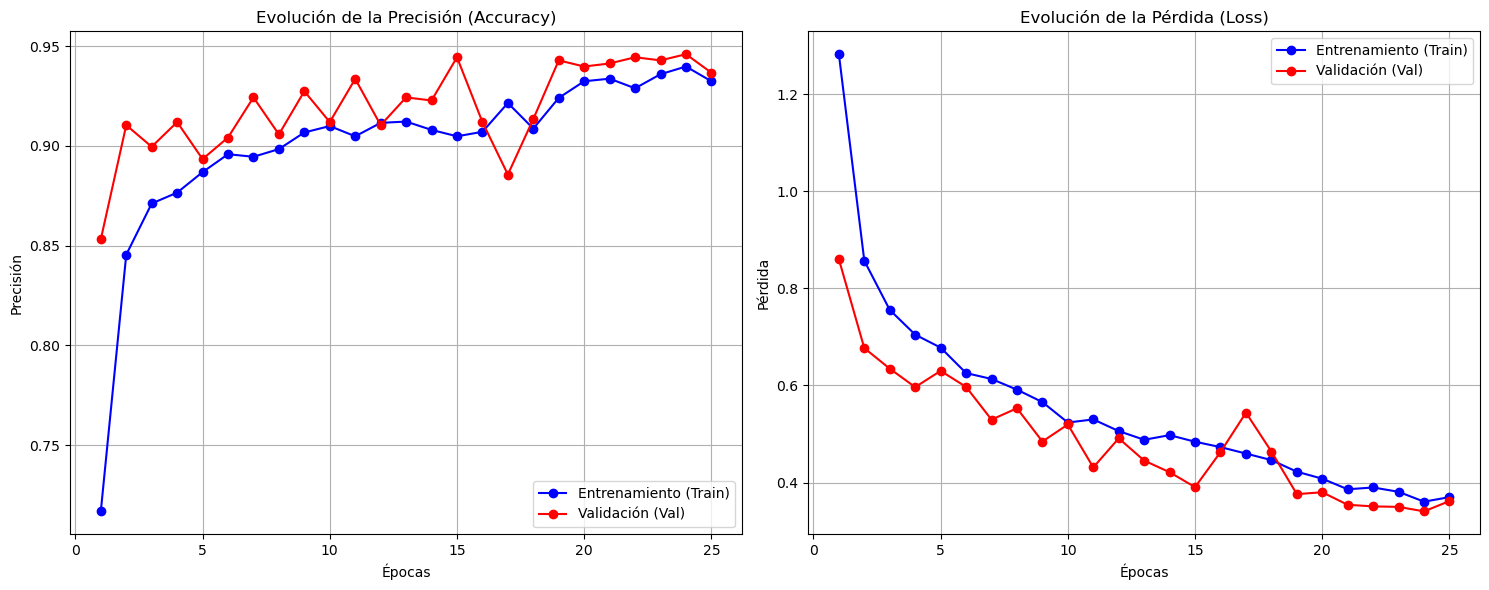

In [8]:
import matplotlib.pyplot as plt

def visualizar_rendimiento(history):
    # Extraemos los datos del objeto history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Creamos una figura con dos subgráficos
    plt.figure(figsize=(15, 6))

    # --- GRÁFICA 1: PRECISIÓN (ACCURACY) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, 'bo-', label='Entrenamiento (Train)')
    plt.plot(epochs_range, val_acc, 'ro-', label='Validación (Val)')
    plt.title('Evolución de la Precisión (Accuracy)')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend(loc='lower right')
    plt.grid(True)

    # --- GRÁFICA 2: PÉRDIDA (LOSS) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, 'bo-', label='Entrenamiento (Train)')
    plt.plot(epochs_range, val_loss, 'ro-', label='Validación (Val)')
    plt.title('Evolución de la Pérdida (Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Ejecutar la función
visualizar_rendimiento(history)

### 9. Validaciones finales

Esta fase del desarrollo se enfoca en la validación final del sistema utilizando datos completamente inéditos para el modelo, garantizando así una evaluación imparcial de su rendimiento industrial.

En estas celdas, se configura un generador específico para el conjunto de Test, el cual hereda la lógica de preprocesamiento CLAHE definida anteriormente para mantener la consistencia en la calidad de imagen. Un aspecto técnico crucial es la desactivación del parámetro shuffle (mezclado); esto asegura que el orden de las imágenes procesadas coincida exactamente con las etiquetas reales, permitiendo un cálculo preciso de la Matriz de Confusión y del Reporte de Clasificación.

A través de esta configuración, se extraen las métricas de Accuracy, Precision, Recall y F1-score exigidas en los requisitos del proyecto, proporcionando la evidencia estadística necesaria para demostrar que el software es capaz de distinguir con éxito entre las 13 categorías mecánicas en condiciones de operación real.

In [9]:
# 2. Creamos el generador de TEST
test_generator = datagen_test.flow_from_directory(
    'dataset_FINAL_OK/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Para que las etiquetas coincidan con las predicciones
)

Found 661 images belonging to 13 classes.


Esta fase del proyecto se dedica a la evaluación exhaustiva y validación estadística de la solución adoptada, permitiendo cuantificar con precisión el rendimiento del modelo ante el problema de clasificación industrial.

El código utiliza las librerías Scikit-learn y Matplotlib para procesar los resultados de la inferencia y generar dos herramientas de diagnóstico clave:

Matriz de Confusión: Se implementa una representación visual térmica que permite identificar de forma inmediata los aciertos (diagonal principal) y los errores específicos entre clases. Esta visualización es fundamental para detectar si existen tipos de tornillos con geometrías tan similares que confundan al algoritmo, permitiendo así justificar posibles áreas de mejora en el preprocesamiento.

Reporte de Clasificación: Se extraen métricas de alto nivel como Precision (fiabilidad), Recall (sensibilidad) y el F1-score (equilibrio entre ambas) para cada una de las 13 categorías.

21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 338ms/step


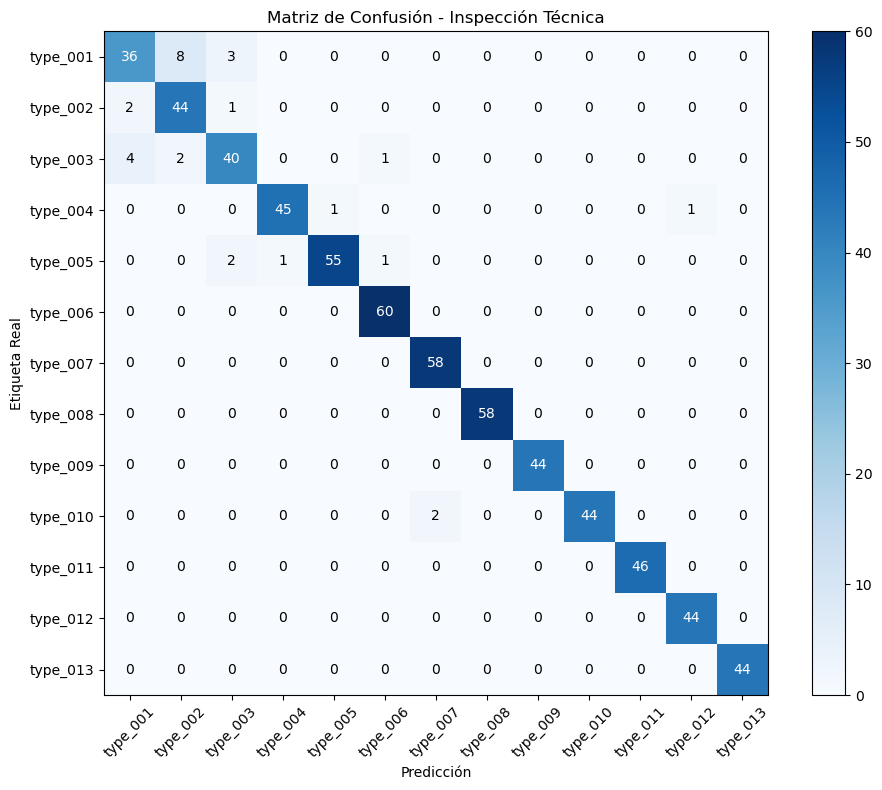

              precision    recall  f1-score   support

    type_001       0.86      0.77      0.81        47
    type_002       0.81      0.94      0.87        47
    type_003       0.87      0.85      0.86        47
    type_004       0.98      0.96      0.97        47
    type_005       0.98      0.93      0.96        59
    type_006       0.97      1.00      0.98        60
    type_007       0.97      1.00      0.98        58
    type_008       1.00      1.00      1.00        58
    type_009       1.00      1.00      1.00        44
    type_010       1.00      0.96      0.98        46
    type_011       1.00      1.00      1.00        46
    type_012       0.98      1.00      0.99        44
    type_013       1.00      1.00      1.00        44

    accuracy                           0.96       647
   macro avg       0.95      0.95      0.95       647
weighted avg       0.96      0.96      0.95       647



In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Predicciones
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# 2. Matriz de Confusión Matplotlib (Lógica de tu práctica)
matriz_conf = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(matriz_conf, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Inspección Técnica')
plt.colorbar()

tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

# Valores en cada celda
thresh = matriz_conf.max() / 2.
for i, j in np.ndindex(matriz_conf.shape):
    plt.text(j, i, format(matriz_conf[i, j], 'd'),
             ha="center", va="center",
             color="white" if matriz_conf[i, j] > thresh else "black")

plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

# 3. Reporte de Clasificación
print(classification_report(y_true, y_pred, target_names=class_labels))

### 10. Creación de interfaz de vídeo con inferencia

Esta etapa final del proyecto representa la fase de despliegue y simulación industrial, donde se valida el funcionamiento de la aplicación en un entorno que emula las condiciones reales de la factoría.

El código implementa una función de inspección dinámica que procesa secuencialmente el conjunto de test para generar un vídeo demostrativo en formato MP4. Durante este proceso, se realizan tres operaciones técnicas fundamentales:

Inferencia y Monitorización de Latencia: Para cada pieza, el modelo realiza una predicción y se mide el tiempo de respuesta exacto utilizando time.perf_counter(). Esta métrica es crucial para justificar la robustez del sistema, demostrando que la latencia de procesamiento (en milisegundos) permite operar en tiempo real a la velocidad de la cinta de 1 m/s.

Interfaz Visual Industrial (HUD): Se utiliza OpenCV para superponer una capa de información gráfica sobre cada fotograma. Esta interfaz muestra en tiempo real la etiqueta real frente a la predicción, el porcentaje de confianza y la latencia. Además, se ha implementado un sistema de retroalimentación cromática, donde un marco verde indica un acierto y uno rojo un error, facilitando la auditoría visual de los resultados.

Generación de Evidencia Técnica: El resultado se codifica mediante el códec mp4v, creando un archivo de vídeo que sirve como prueba definitiva de la exactitud de la solución y la calidad de la exposición.

In [11]:
import cv2
import numpy as np
import time
from tqdm import tqdm

def generar_video_inspeccion(modelo, generador, nombre_archivo='inspeccion_tornillos_final.mp4', fps=2):
    """
    Simula la inspección en cinta, genera una interfaz visual y guarda un vídeo.
    """
    # 1. Configuración del Vídeo
    ancho_v, alto_v = 800, 800  # Resolución del vídeo de salida
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec para MP4
    video_writer = cv2.VideoWriter(nombre_archivo, fourcc, fps, (ancho_v, alto_v))
    
    # Mapeo de etiquetas
    indices_clases = {v: k for k, v in generador.class_indices.items()}
    
    print(f"Generando vídeo: {nombre_archivo}...")
    
    # Reiniciar generador para empezar desde la primera imagen
    generador.reset()
    num_imagenes = len(generador.filenames)
    
    for i in tqdm(range(num_imagenes)):
        # Obtener imagen y etiqueta real
        x_batch, y_batch = next(generador)
        img_preprocesada = x_batch[0]
        label_real = indices_clases[np.argmax(y_batch[0])]
        
        # 2. Inferencia y tiempo
        t_inicio = time.perf_counter()
        pred = modelo.predict(np.expand_dims(img_preprocesada, axis=0), verbose=0)
        t_final = time.perf_counter()
        
        # Resultados
        clase_pred = indices_clases[np.argmax(pred)]
        confianza = np.max(pred) * 100
        latencia = (t_final - t_inicio) * 1000
        
        # 3. Procesar imagen para visualización (Revertir normalización)
        # De [-1, 1] a [0, 255]
        img_vis = ((img_preprocesada + 1.0) * 127.5).astype(np.uint8)
        img_vis = cv2.cvtColor(img_vis, cv2.COLOR_RGB2BGR) # OpenCV usa BGR
        img_vis = cv2.resize(img_vis, (ancho_v, alto_v))
        
        # 4. Dibujar Interfaz (HUD Industrial)
        # Fondo para el texto
        cv2.rectangle(img_vis, (0, 0), (ancho_v, 150), (40, 40, 40), -1)
        
        # Texto: Título y Latencia
        cv2.putText(img_vis, "SISTEMA DE INSPECCION AIVA 2026", (20, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        cv2.putText(img_vis, f"Latencia: {latencia:.2f} ms", (ancho_v - 250, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 1)
        
        # Resultado de Clasificación
        color_resultado = (0, 255, 0) if label_real == clase_pred else (0, 0, 255)
        cv2.putText(img_vis, f"REAL: {label_real}", (20, 90), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        cv2.putText(img_vis, f"PRED: {clase_pred} ({confianza:.1f}%)", (20, 130), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color_resultado, 2)
        
        # Marco de estado
        cv2.rectangle(img_vis, (0, 0), (ancho_v, alto_v), color_resultado, 10)
        
        # Guardar frame y mostrar
        video_writer.write(img_vis)
        cv2.imshow("Simulacion en Tiempo Real", img_vis)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    video_writer.release()
    cv2.destroyAllWindows()
    print(f"Vídeo guardado con éxito como: {nombre_archivo}")

# Ejecutar la creación del vídeo
generar_video_inspeccion(model, test_generator)

Generando vídeo: inspeccion_tornillos_final.mp4...


  0%|          | 0/661 [00:00<?, ?it/s]

100%|██████████| 661/661 [03:09<00:00,  3.49it/s]

Vídeo guardado con éxito como: inspeccion_tornillos_final.mp4
